In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
from collections import Counter
from sklearn.decomposition import PCA
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report, roc_curve, roc_auc_score
from sklearn.metrics import precision_recall_curve, average_precision_score
from sklearn.metrics import PrecisionRecallDisplay

In [16]:
df_original = pd.read_csv('df.csv')
df_original['Malnurished'] = df_original[['Underweight', 'Stunting', 'Wasting']].max(axis=1)
df = df_original.drop(['Underweight', 'Stunting', 'Wasting'], axis = 1)
df.head()

,Child_age,BMI,Children_under5,Total_children_ever_born,Mother_age_current,Mother_education_1,Mother_education_2,Mother_education_3,Wealth_index_1,Wealth_index_2,...,Ethnicity_terai dalit,Ethnicity_newar,Ethnicity_hill janajati,Ethnicity_terai janajati,Child_sex_female,Father_education_1.0,Father_education_2.0,Father_education_3.0,Health_insurance_yes,Malnurished
0,17,22.00,1,1,34,1,0,0,0,0,...,0,0,0,0,1,0,1,0,0,0
1,40,25.10,2,2,26,0,1,0,1,0,...,0,0,1,0,0,1,0,0,0,1
2,59,25.10,2,2,26,0,1,0,1,0,...,0,0,1,0,1,1,0,0,0,1
3,55,21.53,1,1,28,0,1,0,1,0,...,0,0,1,0,1,1,0,0,0,1
4,14,28.03,1,1,26,1,0,0,0,0,...,0,0,1,0,0,0,0,0,0,0


In [17]:
df.shape

(2205, 37)

**Train-test Split**

In [18]:
X = df.drop(columns=['Malnurished'])
y = df['Malnurished']

# Train-test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.20, stratify = y, random_state= 42)

In [19]:
print(y_train.value_counts())
print(y_test.value_counts())

Malnurished
0    1168
1     596
Name: count, dtype: int64
Malnurished
0    292
1    149
Name: count, dtype: int64


**Standard Scaler**

In [20]:
columns_to_scale = ['Child_age', 'BMI', 'Mother_age_current']
scaler = StandardScaler()

X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[columns_to_scale] = scaler.fit_transform(X_train[columns_to_scale])
X_test_scaled[columns_to_scale] = scaler.transform(X_test[columns_to_scale])

In [21]:
X_train_scaled.head()

,Child_age,BMI,Children_under5,Total_children_ever_born,Mother_age_current,Mother_education_1,Mother_education_2,Mother_education_3,Wealth_index_1,Wealth_index_2,...,Ethnicity_hill dalit,Ethnicity_terai dalit,Ethnicity_newar,Ethnicity_hill janajati,Ethnicity_terai janajati,Child_sex_female,Father_education_1.0,Father_education_2.0,Father_education_3.0,Health_insurance_yes
1667,0.445964,-0.935542,2,2,-0.831029,1,0,0,0,0,...,1,0,0,0,0,1,1,0,0,0
383,-0.878122,-1.089744,2,2,-0.641680,1,0,0,0,1,...,0,0,0,0,0,1,0,1,0,0
129,-0.762984,1.024647,1,1,-1.399073,1,0,0,0,1,...,0,0,0,1,0,0,1,0,0,1
541,-1.568950,-0.206352,0,1,-0.262984,0,1,0,0,1,...,0,0,0,0,0,0,1,0,0,0
799,0.273257,2.083150,1,1,1.441151,0,0,0,0,0,...,0,0,1,0,0,0,0,0,0,0


**Visualize the PCA Results**

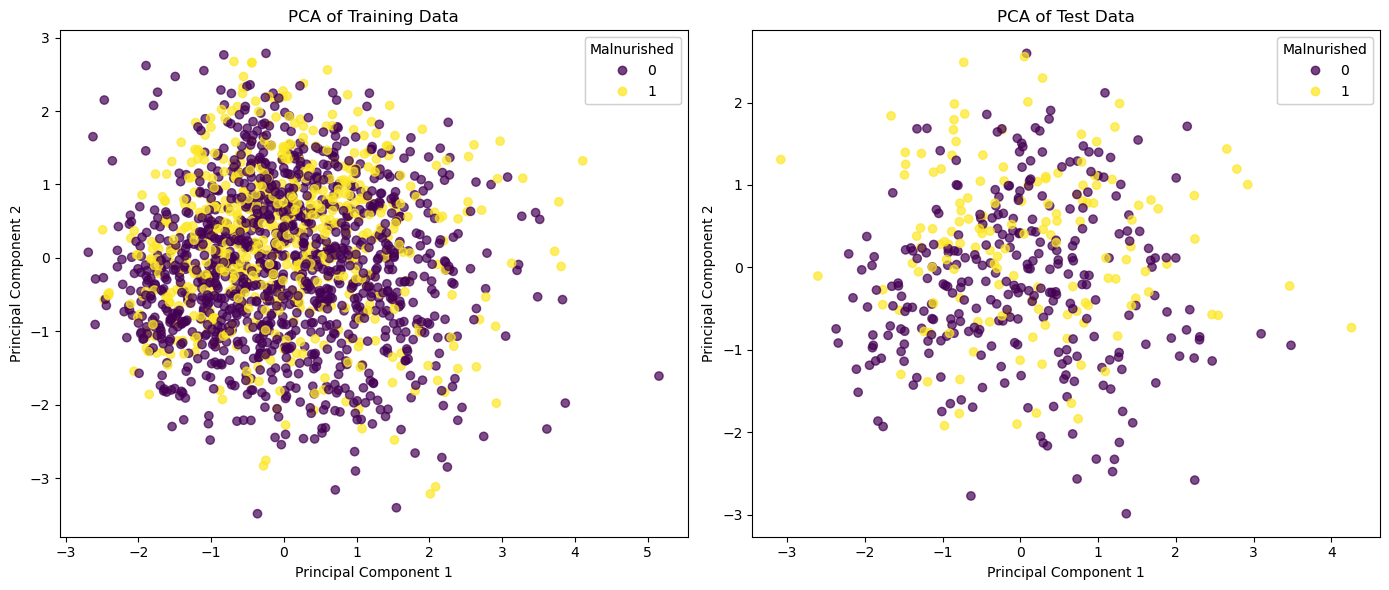

In [22]:
pca = PCA(n_components=2)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Plot for training data
scatter_train = axes[0].scatter(X_train_pca[:, 0], X_train_pca[:, 1], 
                                c=y_train, cmap='viridis', alpha=0.7)
axes[0].set_title("PCA of Training Data")
axes[0].set_xlabel("Principal Component 1")
axes[0].set_ylabel("Principal Component 2")
legend1 = axes[0].legend(*scatter_train.legend_elements(), title="Malnurished")
axes[0].add_artist(legend1)

# Plot for test data
scatter_test = axes[1].scatter(X_test_pca[:, 0], X_test_pca[:, 1], 
                               c=y_test, cmap='viridis', alpha=0.7)
axes[1].set_title("PCA of Test Data")
axes[1].set_xlabel("Principal Component 1")
axes[1].set_ylabel("Principal Component 2")
legend2 = axes[1].legend(*scatter_test.legend_elements(), title="Malnurished")
axes[1].add_artist(legend2)

plt.tight_layout()
plt.show()

### Balancing using SMOTE

In [23]:
sm = SMOTE(random_state=42)
X_train_sm, y_train_sm = sm.fit_resample(X_train_scaled, y_train)
print('Before SMOTE: ', Counter(y_train))
print('After SMOTE: ', Counter(y_train_sm))

Before SMOTE:  Counter({0: 1168, 1: 596})
After SMOTE:  Counter({0: 1168, 1: 1168})


### Cross-validation for Best k

In [24]:
# from sklearn.model_selection import GridSearchCV, StratifiedKFold
# params = {'n_neighbors':range(1, 36), 'weights':['uniform', 'distance'], 'p':[1,2]}

# knn = KNeighborsClassifier()
# cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
# knn_grid_cv = GridSearchCV(knn, param_grid=params, scoring='recall', cv=cv) 
# knn_grid_cv.fit(X_train_sm, y_train_sm)
# print("Best Hyper Parameters:\n",knn_grid_cv.best_params_)
# print("Best CV Recall Score:", knn_grid_cv.best_score_)
# print("Best Estimator:", knn_grid_cv.best_estimator_)


In [25]:
# # Convert GridSearchCV results into DataFrame
# results = pd.DataFrame(knn_grid_cv.cv_results_)

# # Plotting mean recall score vs. n_neighbors
# plt.figure(figsize=(12, 6))

# # Extract mean recall scores for each k-value, grouped by weights and p
# for weight in ['uniform', 'distance']:
#     for p_value in [1, 2]:
#         subset = results[
#             (results['param_weights'] == weight) & 
#             (results['param_p'] == p_value)
#         ]
#         plt.plot(
#             subset['param_n_neighbors'], 
#             subset['mean_test_score'],
#             marker='o',
#             linestyle='--',
#             label=f'weights={weight}, p={p_value}'
#         )

# # Plot labeling
# plt.xlabel('Number of Neighbors (k)')
# plt.ylabel('Mean Recall Score')
# plt.title('Recall Score vs. Number of Neighbors (k)')
# plt.legend()
# plt.grid()
# plt.xticks(range(1, 30, 2))
# plt.show()


## Model Fit

### Default (50%) Threshold

In [26]:
knn = KNeighborsClassifier(n_neighbors=33, metric = 'manhattan')
knn.fit(X_train_sm, y_train_sm)
y_pred = knn.predict(X_test_scaled)

print(f'Confusion Matrix: \n{pd.crosstab(y_test, y_pred)}\n')
print(f'Classification Report: \n{classification_report(y_test, y_pred)}\n')

Confusion Matrix: 
col_0          0    1
Malnurished          
0            122  170
1             37  112

Classification Report: 
              precision    recall  f1-score   support

           0       0.77      0.42      0.54       292
           1       0.40      0.75      0.52       149

    accuracy                           0.53       441
   macro avg       0.58      0.58      0.53       441
weighted avg       0.64      0.53      0.53       441




**Average Precision**

In [27]:
y_pred = knn.predict_proba(X_test_scaled)[:, 1]

print(f'Average Precision Score: {average_precision_score(y_test, y_pred)}')

Average Precision Score: 0.4356259247953307


Always use *predict_proba* or decision function outputs when calculating metrics like AP for an accurate and complete performance assessment.

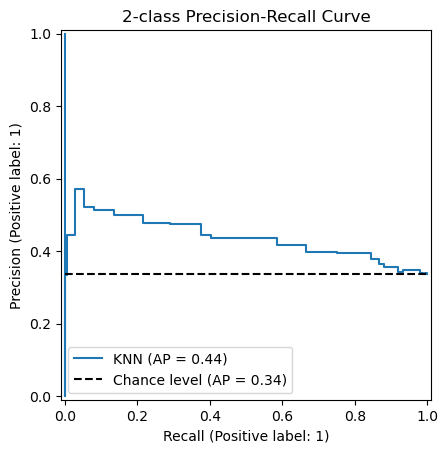

In [36]:
display = PrecisionRecallDisplay.from_estimator(
    knn,                  # Trained model
    X_test_scaled,        # Test features
    y_test,               # True labels
    name="KNN",
    plot_chance_level=True  # Optional, shows baseline
)

display.ax_.set_title("2-class Precision-Recall Curve")
plt.show()


### Threshold Adjustment

**Precision-Recall Threshold**

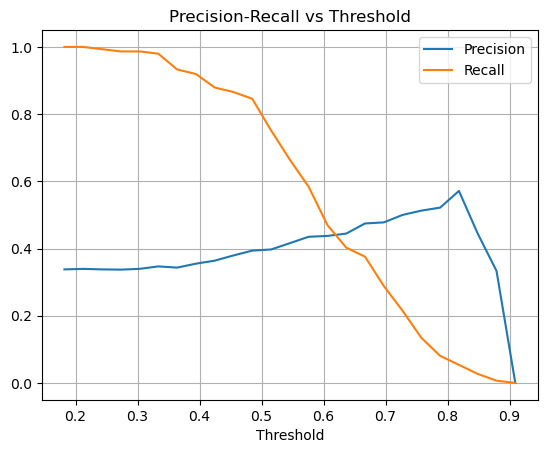

In [37]:
precisions, recalls, thresholds = precision_recall_curve(y_test, y_pred)

plt.plot(thresholds, precisions[:-1], label='Precision')
plt.plot(thresholds, recalls[:-1], label='Recall')
plt.xlabel('Threshold')
plt.legend()
plt.title('Precision-Recall vs Threshold')
plt.grid()
plt.show()

In [38]:
y_probas = knn.predict_proba(X_test_scaled)[:, 1]  # Probabilities for class 1

# Apply custom threshold
y_probas_custom = (y_probas >= 0.40).astype(int)

print(f'Confusion Matrix: \n{pd.crosstab(y_test, y_probas_custom)}\n')
print(f'Classification Report: \n{classification_report(y_test, y_probas_custom)}\n')

Confusion Matrix: 
col_0         0    1
Malnurished         
0            63  229
1            18  131

Classification Report: 
              precision    recall  f1-score   support

           0       0.78      0.22      0.34       292
           1       0.36      0.88      0.51       149

    accuracy                           0.44       441
   macro avg       0.57      0.55      0.43       441
weighted avg       0.64      0.44      0.40       441




**Average Precision Custom**

In [ ]:
print(f'Average Precision Score: {average_precision_score(y_test, y_probas_custom)}')

**Feature Selection**

In [ ]:
from sklearn.feature_selection import SequentialFeatureSelector

selector = SequentialFeatureSelector(knn, n_features_to_select=10, direction='forward')
selector.fit(X_train_scaled, y_train)

selected_features = X_train.columns[selector.get_support()]
print("Sequentially selected:", list(selected_features))


## Optional

**ROC-AUC Score**

In [ ]:
auc = roc_auc_score(y_test, knn.predict_proba(X_test_scaled)[:,1])
print(f'ROC-AUC Score: {auc:.4f}')

1. Separate performance score for train and test sets
2. Do the average precision score change in custom threshold